# 序列模型


## 序列数据
实际中很多数据有时序结构
- 语言
- 视频音频
- 时间序列数据

## 统计工具
- 在 $t$ 时刻观察到 $x_t$， 得到 $T$ 个不独立随机变量 $\mathbf{x}=(x_1, ..., x_T)$
- 机器学习模型对 $p(\mathbf{x})$ 建模
- 条件概率展开
$$p(\mathbf{x}) = \prod_{t=1}^{T} p(x_t|x_1, ..., x_{t-1})$$
$$p(\mathbf{x}) = \prod_{t=T}^{1} p(x_t|x_{t+1}, ..., x_{T})$$

### 自回归
对条件概率建模，如果本轮 $f$ 来自上一轮的输出，则称为自回归
$$p(x_t|x_1, ..., x_{t-1}) = p\left(x_t|f(x_1, ..., x_{t-1})\right)$$

## 建模方案
### 马尔科夫假设
假设 $x_t$ 只依赖于前 $\tau$ 个时刻的观测值。只需处理定长数据，直接用 MLP 建模就可以。
$$p(x_t|x_1, ..., x_{t-1}) = p(x_t|x_{t-\tau}, ..., x_{t-1})$$

### 潜变量模型
引入潜变量 $h_t$ 来表示过去信息。
$$h_t = f(x_1, ..., x_{t-1})$$
$$p(x_t|x_1, ..., x_{t-1}) = p(x_t|h_t)$$


## 实现


In [2]:
%matplotlib inline
import torch
from torch import nn
import util

使用正弦函数加一些噪音作为时序数据，1000 个时间步


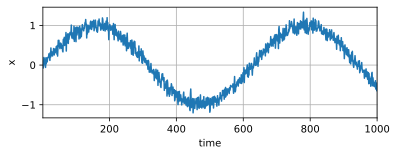

In [70]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
X = torch.sin(0.01 * time) + torch.normal(0, 0.1, (T,))
util.plot(time, [X], 'time', 'x', xlim=[1, 1000], figsize=(6, 2))

将数据映射为数据对 $y_t = x_t$ 和 $X_t = (x_{t-\tau}, ..., x_{t-1})$，其中 $\tau=4$。


In [71]:
tau = 4
features = torch.zeros((T - tau, tau)) # (时间步, 特征数tau)
for i in range(tau):
    features[:, i] = X[i: T - tau + i]
labels = X[tau:].reshape((-1, 1)) # (时间步, 1) 下一个时间步

batch_size = 16
n_train = 600 # 自回归起点
train_iter = util.data.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

简单 MLP 建模


In [72]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(tau, 128),
                        nn.ReLU(),
                        nn.Linear(128, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss()

训练


In [73]:
def train(net, train_iter, num_epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            trainer.step()
        print(f'epoch {epoch + 1}, loss {l.item():f}')

net = get_net()
train(net, train_iter, num_epochs=5, lr=0.001)

epoch 1, loss 0.040797
epoch 2, loss 0.013821
epoch 3, loss 0.008332
epoch 4, loss 0.006531
epoch 5, loss 0.007584


单步预测，即用真实值作为输入预测下一个时间步。基本完全拟合。


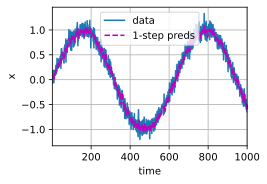

In [74]:
onestep_preds = net(features)
util.plot(
    [time, time[tau:]],
    [X.detach().numpy(), onestep_preds.detach().numpy()],
    'time', 'x',
    legend=['data', '1-step preds'], xlim=[1, 1000]
)

自回归试试，用自己预测的值一直往后预测。可以看到维持不了多久就偏得很离谱


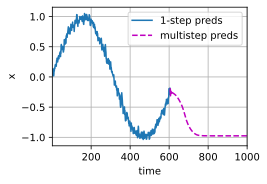

In [75]:
multistep_preds = torch.zeros(T)
multistep_preds[:n_train + tau] = X[:n_train + tau] # 前 n_train + tau 个时间步的预测值为真实值
for i in range(n_train + tau, T): # 从 n_train + tau 开始预测
    # 使用前 tau 个时间步的预测值作为输入，预测下一个时间步的值
    multistep_preds[i] = net(multistep_preds[i - tau:i].reshape(1, -1)) # (tau,) -> (1, tau)
util.plot(
    [time[:n_train + tau], # n_train + tau 前是单步预测值
     time[n_train + tau:]], # n_train + tau 后是多步（自回归）预测值
    [onestep_preds.detach().numpy()[:n_train + tau], # 单步预测
     multistep_preds[n_train + tau:].detach().numpy()], # 自回归预测
    'time', 'x',
    legend=['1-step preds', 'multistep preds'], xlim=[1, 1000]
)

更仔细看一下 k 步预测


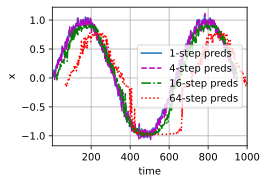

In [76]:
max_steps = 64

features = torch.zeros((T - tau - max_steps + 1, tau + max_steps)) # (时间步, 特征数 + 预测步数)
for i in range(tau + max_steps):
    features[:, i] = X[i: i + T - tau - max_steps + 1] # 先把真实值放进去
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1) # 从 tau 开始逐个用预测值替换，reshape (B, 1) -> (B,)

steps = [1, 4, 16, 64]
util.plot(
    [time[tau + i - 1: T - max_steps + i] for i in steps], # 每一种步数走过的时间步
    [features[:, tau + i - 1].detach().numpy() for i in steps], # 每一种步数的预测值
    'time', 'x',
    legend=[f'{i}-step preds' for i in steps], xlim=[1, 1000]
)

可以看出预测步数越长，偏差越大。因此基于马尔可夫假设的 MLP 模型不适合自回归预测。
